# `jlx` Demo — matplotlib and pandas

A small, real notebook used as a fixture for the `jlx` command line tool. It
exists to prove two things at once:

1. **`jlx run` executes the notebook the way the browser does.** The sine wave
   below is drawn by matplotlib and the table by pandas, and both are saved back
   into this `.ipynb` as an embedded PNG and rendered HTML.
2. **`%%extract` fires during that headless run.** The two extract cells stack
   into one importable module at `demo_outputs/analysis.py`.

**Note:** This notebook is paired with a `.py` script via Jupytext. Always run
from the `.ipynb` — the `.py` is for version control and diffing only, since
cell magics need a live kernel.

Run it with:

```bash
jlx run tests/demo_plots.ipynb
```

## Setup

In [1]:
%load_ext jupyter_lab_extractor

In [2]:
import shutil
from pathlib import Path

# %%extract appends with -a, so clear the directory to keep re-runs idempotent.
OUTPUT_DIR = Path("demo_outputs")
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)
print(f"Output directory ready: {OUTPUT_DIR}/")

Output directory ready: demo_outputs/


## The sine wave

The magic line is stripped from the extracted file, so `analysis.py` gets a
clean `import` block and the function definition — nothing that only means
something inside a kernel.

In [3]:
%%extract demo_outputs/analysis.py -w
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def sine_wave(cycles=1, points=200):
    """x and sin(x) over `cycles` full periods."""
    x = np.linspace(0, cycles * 2 * np.pi, points)
    return x, np.sin(x)

Plotting happens in a plain cell, so the figure lands in the notebook while `analysis.py` stays importable without side effects:

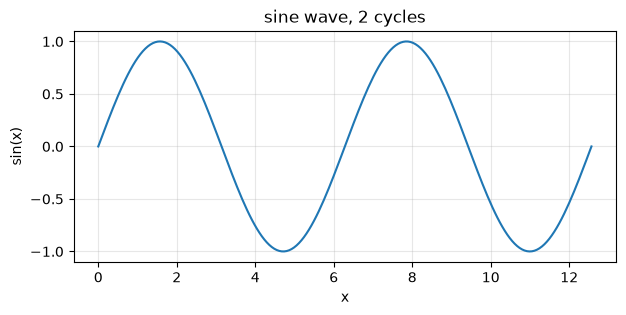

In [4]:
x, y = sine_wave(cycles=2)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y, color="tab:blue")
ax.set_title("sine wave, 2 cycles")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.grid(alpha=0.3)
plt.show()

## The DataFrame

A second extract cell, this time with `-a`, so it appends to the same file. The
two blocks stack into one module, each with its own `# Source:` header.

In [5]:
%%extract demo_outputs/analysis.py -a
def sine_table(cycles=1, points=5):
    """The same sine wave as a DataFrame."""
    x, y = sine_wave(cycles=cycles, points=points)
    return pd.DataFrame({"x": x, "sin_x": y})

In [6]:
df = sine_table(cycles=1, points=5)
df

,x,sin_x
0,0.000000,0.000000e+00
1,1.570796,1.000000e+00
2,3.141593,1.224647e-16
3,4.712389,-1.000000e+00
4,6.283185,-2.449294e-16


## What ended up in the file

Both blocks, headers included, and no magic lines.

In [7]:
print(Path("demo_outputs/analysis.py").read_text(encoding="utf-8"))

# Source: tests/demo_plots.ipynb | Cell In[4] | 2026-08-31 12:56:18
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def sine_wave(cycles=1, points=200):
    """x and sin(x) over `cycles` full periods."""
    x = np.linspace(0, cycles * 2 * np.pi, points)
    return x, np.sin(x)

# Source: tests/demo_plots.ipynb | Cell In[6] | 2026-08-31 12:56:18
def sine_table(cycles=1, points=5):
    """The same sine wave as a DataFrame."""
    x, y = sine_wave(cycles=cycles, points=points)
    return pd.DataFrame({"x": x, "sin_x": y})


